# Spectral decomposition closure 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance,
    compute_variance_groupby,
    compute_variance,
    put_fig_letter,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine


from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DT = 3
distance_to_coast_max = 20e3

In [72]:
band = ["", "LF", "diurnal", "inertial", "semidiurnal", "HF"]

# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess="spectral_decomp",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)


comb_list = [update_dict(base_dic, {"drifter_preprocess_param": b}) for b in band]


ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0 = ds0.where(ds0.depth == 0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
# ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast > distance_to_coast_max, drop=True)
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)
df0_ = ds0.to_dataframe().reset_index().set_index("row_number")


# DEPTH 15M
base_dic = update_dict(base_dic, {"wd_depth": "15"})

comb_list = [update_dict(base_dic, {"drifter_preprocess_param": b}) for b in band]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15 = ds15.where(ds15.depth == 15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
# ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast > distance_to_coast_max, drop=True)

# Correct mean geostrophic
df15_ = ds15.to_dataframe().reset_index().set_index("row_number")

df0_["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df0_.latitude * np.pi / 180)
df15_["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df15_.latitude * np.pi / 180)

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__semidiurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__HF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__inertia

In [73]:
ds0["id_comb"] = ["all"] + band[1:]
ds15["id_comb"] = ["all"] + band[1:]

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

DS = DS.where(
    (abs(DS.sel(id_comb="HF").acce) < 5e-5) & (abs(DS.sel(id_comb="HF").accn) < 5e-5)
)

ds = (compute_variance(DS, compute_error="centrallimit") / U2).rename(
    {"id_comb": "Frequency band"}
)

df = ds.to_dataframe().reset_index()
df["Frequency band"] = ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"]
df = df.set_index("Frequency band")

DS0 = ds0.where(ds0.depth == 0, drop=True)
DS0 = DS0.where(DS0.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS0 = DS0.where(DS0.distance_to_coast > distance_to_coast_max, drop=True)
DS0 = DS0.where(
    (abs(DS0.sel(id_comb="HF").acce) < 5e-5) & (abs(DS0.sel(id_comb="HF").accn) < 5e-5)
)  # outliers
ds0 = (compute_variance(DS0, compute_error="centrallimit") / U2).rename(
    {"id_comb": "Frequency band"}
)
df0 = ds0.to_dataframe().reset_index()
df0["Frequency band"] = ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"]
df0 = df0.set_index("Frequency band")


DS15 = ds15.where(ds15.depth == 15, drop=True)
DS15 = DS15.where(DS15.time_to_swot / pd.Timedelta("1h") < DT).dropna("row_number")
DS15 = DS15.where(DS15.distance_to_coast > distance_to_coast_max, drop=True)
DS15 = DS15.where(
    (abs(DS15.sel(id_comb="HF").acce) < 5e-5)
    & (abs(DS15.sel(id_comb="HF").accn) < 5e-5)
)  # outliers
ds15 = (compute_variance(DS15, compute_error="centrallimit") / U2).rename(
    {"id_comb": "Frequency band"}
)
df15 = ds15.to_dataframe().reset_index()
df15["Frequency band"] = ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"]
df15 = df15.set_index("Frequency band")

2115
1171
944


In [74]:
df0 = df0.rename(index={'Total':'Full-spectrum'})
df15 = df15.rename(index={'Total':'Full-spectrum'})

In [75]:
f0 = df0_.f.mean()
f15 = df15_.f.mean()

# Errors

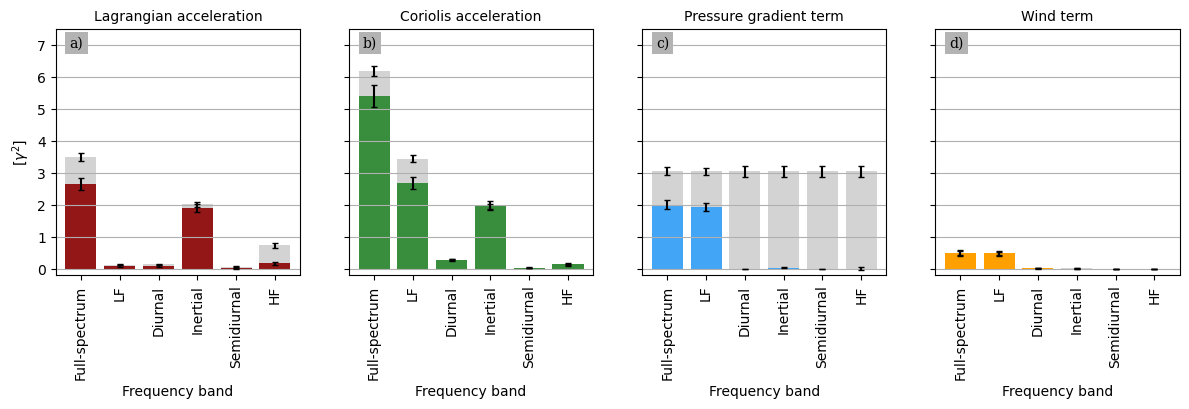

In [8]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(
    1, 4, figsize=(14.5, 3.2), frameon=False, sharex=True, sharey=True
)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df["B_" + vars[j]],
        yerr=df["er__E_" + vars[j]],
        **kwargs
    )
    df["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]], fontsize=10)
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

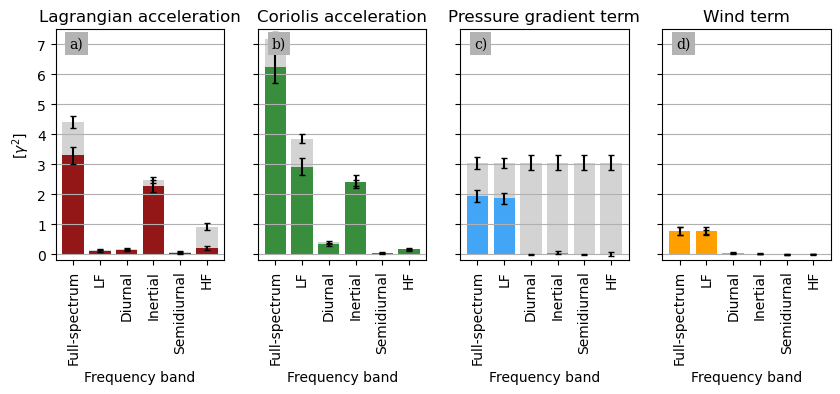

In [9]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize=(10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df0["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df0["B_" + vars[j]],
        yerr=df0["er__E_" + vars[j]],
        **kwargs
    )
    df0["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df0["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

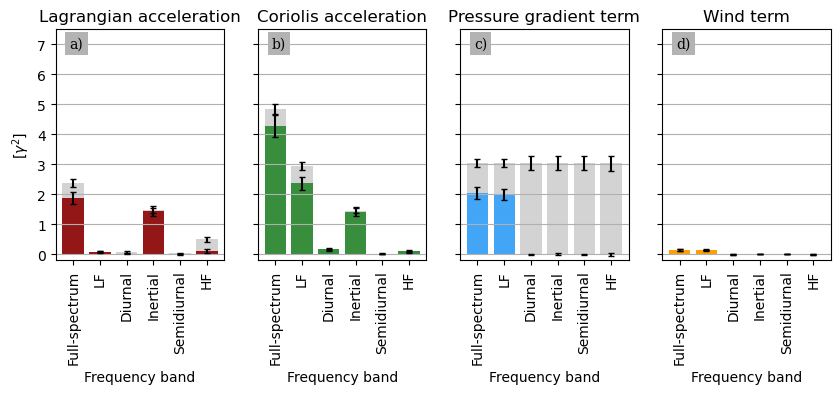

In [10]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize=(10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df15["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df15["B_" + vars[j]],
        yerr=df15["er__E_" + vars[j]],
        **kwargs
    )
    df15["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df15["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

In [11]:
df[["E_" + v for v in vars]], df[["er__E_" + v for v in vars]]

(                   E_acc     E_cor     E_ggd      E_wd
 Frequency band                                        
 Full-spectrum   0.841095  0.779648  1.053264  0.004812
 LF              0.031526  0.757104  1.125092 -0.035151
 Diurnal         0.051824  0.006866  3.058176 -0.005163
 Inertial        0.113884 -0.019389  3.014892  0.008135
 Semidiurnal     0.045044 -0.009703  3.060193 -0.000595
 HF              0.562420 -0.033201  3.040673  0.008698,
                 er__E_acc  er__E_cor  er__E_ggd  er__E_wd
 Frequency band                                           
 Full-spectrum    0.123986   0.153882   0.125631  0.075229
 LF               0.017699   0.103506   0.114323  0.051746
 Diurnal          0.020402   0.028320   0.175225  0.007404
 Inertial         0.071391   0.069814   0.173882  0.007850
 Semidiurnal      0.014340   0.009271   0.173986  0.001934
 HF               0.065185   0.022302   0.177086  0.006646)

In [12]:
df[["B_" + v for v in vars]], df[["er__B_" + v for v in vars]]

(                   B_acc     B_cor     B_ggd      B_wd
 Frequency band                                        
 Full-spectrum   2.659331  5.405374  2.004837  0.499448
 LF              0.098418  2.691115  1.933009  0.506037
 Diurnal         0.092747  0.289762 -0.000075  0.028257
 Inertial        1.908271  1.977050  0.043209  0.010815
 Semidiurnal     0.025891  0.039612 -0.002092  0.001967
 HF              0.174783  0.154039  0.017428  0.001506,
                 er__B_acc  er__B_cor  er__B_ggd  er__B_wd
 Frequency band                                           
 Full-spectrum    0.189233   0.335054   0.139973  0.085187
 LF               0.018485   0.186669   0.125982  0.068863
 Diurnal          0.021793   0.030531   0.012428  0.007776
 Inertial         0.134532   0.135691   0.022296  0.007417
 Semidiurnal      0.013958   0.009618   0.009419  0.001921
 HF               0.049698   0.024065   0.041368  0.006161)

# Paired contributions

In [13]:
df.index

Index(['Full-spectrum', 'LF', 'Diurnal', 'Inertial', 'Semidiurnal', 'HF'], dtype='object', name='Frequency band')

In [14]:
def plot_(df, axs, i0):
    i = i0
    for b in ["Full-spectrum", "LF", "Inertial", "HF"]:
        df_ = df.loc[b]
        ax = axs[i]

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            0,
            df_["X_acc_cor"],
            color=c0["acc"],
            hatch="/",
            yerr=df_["er__X_acc_cor"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["ggd"]
        ax.bar(
            1,
            df_.X_acc_ggd,
            color=c0["acc"],
            hatch="/",
            yerr=df_["er__X_acc_ggd"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            2,
            df_.X_cor_ggd,
            color=c0["ggd"],
            hatch="/",
            yerr=df_["er__X_cor_ggd"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            3,
            df_.X_cor_wd,
            color=c0["wd"],
            hatch="/",
            yerr=df_["er__X_cor_wd"],
            capsize=2,
        )

        # plt.rcParams["hatch.color"] = c0['ggd']
        # ax.bar(5, df_.X_ggd_wd,color = c0['wd'], hatch="/",  yerr =df_['er__X_ggd_wd'], capsize=2)
        # plt.rcParams["hatch.color"] = c0['acc']
        # ax.bar(4,df_.X_acc_wd,color = c0['wd'], hatch="/", yerr =df_['er__X_acc_wd'], capsize=2)
        if i < 4:
            ax.set_title(b)
        L = ["c", "d", "e", "f", "g", "h", "i", "j"]
        put_fig_letter(fig, axs[i], L[i])

        i += 1
        print(b)

    # Resolution mismatch errors
    kwargs = dict(width=0.8, capsize=2)
    plt.rcParams["hatch.color"] = "lightgrey"
    axs[i0 + 1].bar(
        2.5,
        df.E_cor.loc["LF"] * 2,
        bottom=6,
        yerr=df.er__E_cor.loc["LF"] * 2,
        color="lightgrey",
        **kwargs,
    )
    axs[i0 + 3].bar(
        1,
        df.E_acc.loc["HF"] * 2,
        yerr=df.er__E_acc.loc["HF"] * 2,
        color="lightgrey",
        bottom=3,
        **kwargs,
        label="Resolution \n mismatch errors",
    )

Full-spectrum
LF
Inertial
HF
Full-spectrum
LF
Inertial
HF


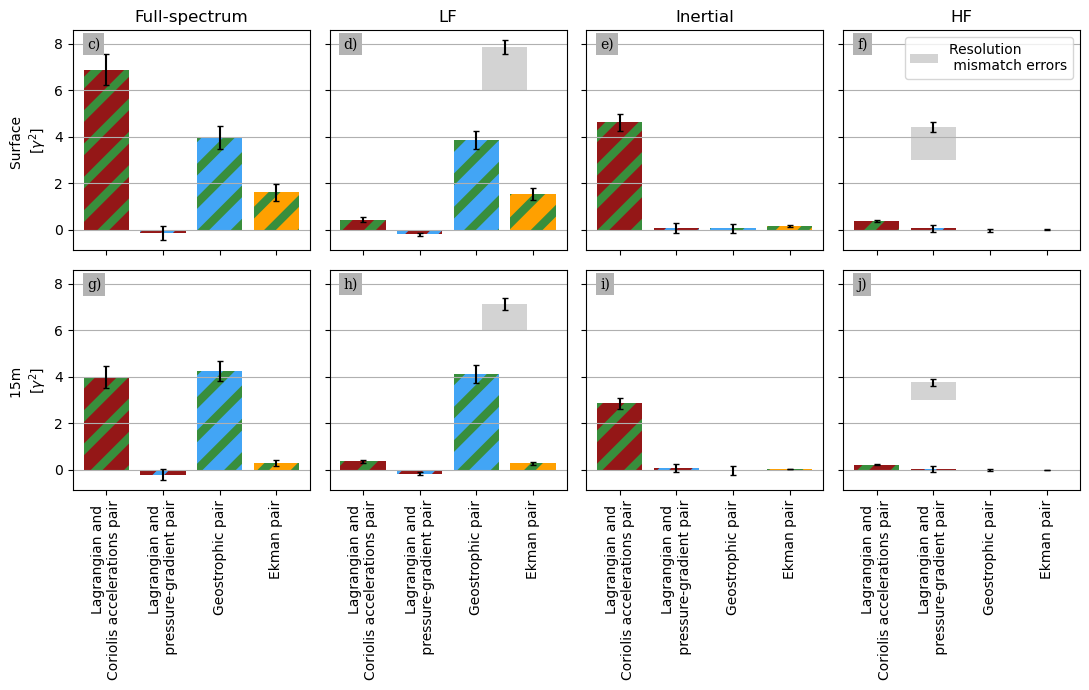

In [15]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 4, figsize=(11, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
plot_(df0, axs, 0)
plot_(df15, axs, 4)
i=0
for ax in axs:
    ax.grid(axis="y")
    ax.set_xticks(
        [0, 1, 2, 3],
        [
            "Lagrangian and \nCoriolis accelerations pair",
            "Lagrangian and \n pressure-gradient pair",
            "Geostrophic pair",
            "Ekman pair",
        ],
        rotation=90,
        ha="right",
        va="center",
        rotation_mode="anchor",
    )
    i+=1
axs[0].set_ylabel("Surface \n" + r"[$\gamma^2$]")
axs[4].set_ylabel("15m \n" + r"[$\gamma^2$]")
axs[3].legend()
fig.tight_layout()

### Equivalent velocities STD

In [15]:
def velocities(dm, f, v):
    e = np.sqrt(dm[v] / (f**2) * U2 / 2)
    er = e * 1 / 2 * (dm["er__" + v] / dm[v])
    print(
        "Velocities "
        + v
        + f" :    {np.round(e*100, 1)}\pm {np.round(er*100, 1)} cm.s-1"
    )

In [16]:
velocities(df0.loc["LF"], f0, "B_wd"), velocities(df15.loc["LF"], f15, "B_wd")

Velocities B_wd :    6.6\pm 0.5 cm.s-1
Velocities B_wd :    3.0\pm 0.3 cm.s-1


(None, None)

In [17]:
velocities(df0.loc["LF"], f0, "B_ggd"), velocities(df15.loc["LF"], f15, "B_ggd")

Velocities B_ggd :    10.1\pm 0.5 cm.s-1
Velocities B_ggd :    10.3\pm 0.5 cm.s-1


(None, None)

In [18]:
velocities(df0.loc["Inertial"], f0, "B_acc"), velocities(
    df15.loc["Inertial"], f15, "B_acc"
)

Velocities B_acc :    11.2\pm 0.5 cm.s-1
Velocities B_acc :    8.8\pm 0.5 cm.s-1


(None, None)

/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2404017841.py:64: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate(
/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2404017841.py:74: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate(


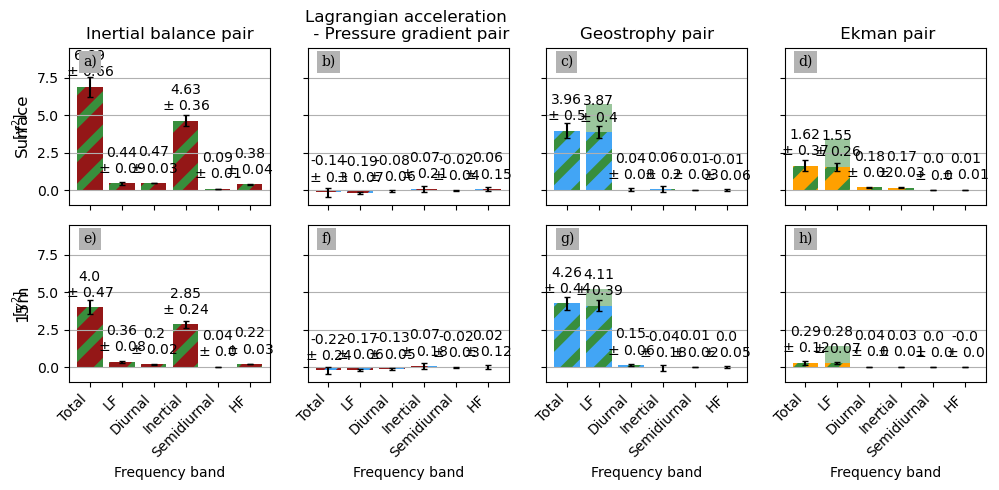

In [19]:
def print_labels(df, X, ax):
    for i in range(0, 6):
        # SX = df.iloc[i][[v for v in df.columns if ('X_' in v)&('er__' not in v)]].sum()
        # SX = df.loc['Full-spectrum'].X_cor_ggd
        # erSX = df.loc['Full-spectrum'].er__X_cor_ggd

        label = (
            rf"{np.round(df[X].iloc[i], 2)}"
            + "\n"
            + rf"$\pm$ {np.round(df['er__' + X].iloc[i], 2)}"
        )
        # if i in [1,2, 3, 4] :
        #    label = label + '\n' + rf"{int(df[X].iloc[i]/SX*100)} $\pm$ {int(df[X].iloc[i]/SX*100*((df['er__'+X]/df[X]).iloc[i] + erSX/SX))}%"
        ax.text(
            i,
            df[X].iloc[i] + 0.5,
            label,
            horizontalalignment="center",
            verticalalignment="bottom",
            rotation=0,
        )


plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(2, 4, figsize=(10, 5), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/", width=0.8, capsize=2)


def plot(df_, axs, init):
    ax = axs[init + 0]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_acc_cor.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__X_acc_cor"], **kwargs)
    print_labels(df_, "X_acc_cor", ax)

    ax = axs[init + 1]
    plt.rcParams["hatch.color"] = c0["ggd"]
    df_.X_acc_ggd.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__X_acc_ggd"], **kwargs)
    print_labels(df_, "X_acc_ggd", ax)

    ax = axs[init + 2]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_cor_ggd.plot.bar(color=c0["ggd"], ax=ax, yerr=df_["er__X_cor_ggd"], **kwargs)
    print_labels(df_, "X_cor_ggd", ax)

    ax = axs[init + 3]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_cor_wd.plot.bar(color=c0["wd"], ax=ax, yerr=df_["er__X_cor_wd"], **kwargs)
    print_labels(df_, "X_cor_wd", ax)


plot(df0, axs, 0)
plot(df15, axs, 4)

axs[0].set_title("Inertial balance pair")
axs[1].set_title("Lagrangian acceleration \n - Pressure gradient pair")
axs[2].set_title("Geostrophy pair")
axs[3].set_title(" Ekman pair")

pad = 0
axs[0].annotate(
    "Surface",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)
axs[4].annotate(
    "15m",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)

l = ["a", "b", "c", "d", "e", "f", "g", "h"]
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

for ax in axs:
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_xticks(
        [0, 1, 2, 3, 4, 5],
        ["Full-spectrum", "LF", "Diurnal", "Inertial", "Semidiurnal", "HF"],
        rotation=45,
        ha="right",
    )

axs[0].set_ylim(-1, 9.5)

#### Add Possible paired contributions from resolution mismatch ####

axs[2].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_ggd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[3].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_wd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[6].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_ggd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
axs[7].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_wd.loc["LF"],
    color=c0["cor"],
    alpha=0.5,
)
# (df0.E_cor.loc['LF']*2).plot.bar(x=1, ax=axs[3], bottom = df0.X_cor_ggd.loc['LF'], color = 'lightgrey')

fig.tight_layout()

In [20]:
df0.E_cor

Frequency band
Total          0.949218
LF             0.928142
Diurnal        0.061217
Inertial      -0.058204
Semidiurnal   -0.010585
HF            -0.035628
Name: E_cor, dtype: float64

# Percentage of Balanced signal

In [76]:
for df in [df0, df15]:
    #df["B"] = df[[v for v in df.columns if ("X_" in v) & ("er__" not in v)]].sum(axis=1)
    df["B"] = df[[v for v in df.columns if ("X_" in v) & ("er__" not in v) & ('percentage' not in v)]].sum(axis=1).iloc[0]
    df["er__B"] = df[[v for v in df.columns if ("er__X_" in v)]].sum(axis=1).iloc[0]
    for X in [v for v in df.columns if ("X_" in v) & ("er__" not in v)]:
        df[X + "B_percentage"] = df[X] / df["B"]
        df["er__" + X + "B_percentage"] = df[X + "B_percentage"] * np.sqrt(
            (df["er__" + X] / df[X]) ** 2 + (df["er__B"] / df["B"]) ** 2
        )

In [77]:
[v for v in df.columns if ("X_" in v) & ("er__" not in v) & ('percentage' not in v)]

['X_acc_cor', 'X_acc_ggd', 'X_acc_wd', 'X_cor_ggd', 'X_cor_wd', 'X_ggd_wd']

In [78]:
df0[
    [
        X
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
]

,X_acc_cor,X_acc_ggd,X_acc_wd,X_cor_ggd,X_cor_wd,X_ggd_wd
Frequency band,,,,,,
Full-spectrum,6.889512,-0.138941,-0.148429,3.963281,1.623076,0.085627
LF,0.440777,-0.193618,-0.032364,3.867291,1.551980,0.058578
Diurnal,0.468520,-0.076754,-0.092168,0.035338,0.180164,0.025883
Inertial,4.630280,0.074631,-0.123324,0.064735,0.167164,-0.009434
Semidiurnal,0.091099,-0.018753,-0.001257,0.008462,0.002483,0.003286
HF,0.384576,0.059151,-0.004599,-0.012937,0.010192,-0.002800


In [79]:
df0[
    [
        "er__" + X
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
]

,er__X_acc_cor,er__X_acc_ggd,er__X_acc_wd,er__X_cor_ggd,er__X_cor_wd,er__X_ggd_wd
Frequency band,,,,,,
Full-spectrum,0.661911,0.298474,0.148174,0.496979,0.365027,0.167632
LF,0.093950,0.069496,0.035218,0.398888,0.262634,0.148312
Diurnal,0.030229,0.061586,0.007507,0.083845,0.015882,0.024535
Inertial,0.362990,0.206444,0.028614,0.200968,0.030253,0.027099
Semidiurnal,0.007276,0.043163,0.001311,0.028461,0.000875,0.006498
HF,0.042233,0.146063,0.011524,0.060374,0.005301,0.019327


In [80]:
df0[
    [
        X + "B_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,X_acc_corB_percentage,X_acc_ggdB_percentage,X_acc_wdB_percentage,X_cor_ggdB_percentage,X_cor_wdB_percentage,X_ggd_wdB_percentage
Frequency band,,,,,,
Full-spectrum,56.130365,-1.131983,-1.209280,32.289716,13.223559,0.697624
LF,3.591103,-1.577449,-0.263674,31.507669,12.644322,0.477251
Diurnal,3.817132,-0.625334,-0.750915,0.287906,1.467839,0.210872
Inertial,37.723905,0.608034,-1.004751,0.527406,1.361920,-0.076858
Semidiurnal,0.742200,-0.152783,-0.010243,0.068944,0.020231,0.026771
HF,3.133225,0.481913,-0.037469,-0.105402,0.083040,-0.022809


In [81]:
df0[
    [
        "er__" + X + "B_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,er__X_acc_corB_percentage,er__X_acc_ggdB_percentage,er__X_acc_wdB_percentage,er__X_cor_ggdB_percentage,er__X_cor_wdB_percentage,er__X_ggd_wdB_percentage
Frequency band,,,,,,
Full-spectrum,11.166606,-2.439715,-1.225449,6.930720,3.761777,1.371134
LF,0.988553,-0.629364,-0.290582,6.378697,3.070883,1.211185
Diurnal,0.709101,-0.513441,-0.144404,0.684939,0.286579,0.203241
Inertial,7.206416,1.685278,-0.291518,1.639908,0.342110,-0.221189
Semidiurnal,0.142236,-0.352667,-0.010830,0.232189,0.007950,0.053146
HF,0.645221,1.192966,-0.094112,-0.492220,0.045548,-0.157510


In [82]:
df15[
    [
        X
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
]

,X_acc_cor,X_acc_ggd,X_acc_wd,X_cor_ggd,X_cor_wd,X_ggd_wd
Frequency band,,,,,,
Full-spectrum,3.997903,-0.215718,-0.035158,4.257886,0.294674,0.042335
LF,0.355685,-0.167127,-0.012666,4.112517,0.275050,0.067139
Diurnal,0.200558,-0.126873,-0.025962,0.148071,0.037836,-0.023830
Inertial,2.854868,0.073126,-0.024908,-0.038006,0.033952,-0.002176
Semidiurnal,0.041423,-0.018436,0.000284,0.012925,0.000117,0.003434
HF,0.216194,0.021841,0.004147,0.002433,-0.000290,-0.000496


In [83]:
df15[
    [
        "er__" + X
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
]

,er__X_acc_cor,er__X_acc_ggd,er__X_acc_wd,er__X_cor_ggd,er__X_cor_wd,er__X_ggd_wd
Frequency band,,,,,,
Full-spectrum,0.471422,0.237787,0.063955,0.442076,0.121096,0.047972
LF,0.076947,0.062782,0.011245,0.389618,0.070316,0.049391
Diurnal,0.021741,0.045806,0.002925,0.058262,0.004124,0.009243
Inertial,0.240634,0.179591,0.007621,0.179659,0.008284,0.008607
Semidiurnal,0.004386,0.032450,0.000282,0.020918,0.000188,0.002407
HF,0.025647,0.118213,0.003455,0.050425,0.001282,0.006415


In [84]:
df15[
    [
        X + "B_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,X_acc_corB_percentage,X_acc_ggdB_percentage,X_acc_wdB_percentage,X_cor_ggdB_percentage,X_cor_wdB_percentage,X_ggd_wdB_percentage
Frequency band,,,,,,
Full-spectrum,47.925440,-2.585950,-0.421467,51.042034,3.532443,0.507500
LF,4.263821,-2.003458,-0.151836,49.299402,3.297207,0.804837
Diurnal,2.404216,-1.520915,-0.311226,1.775017,0.453559,-0.285666
Inertial,34.223142,0.876614,-0.298589,-0.455606,0.407003,-0.026091
Semidiurnal,0.496559,-0.221004,0.003410,0.154939,0.001408,0.041171
HF,2.591662,0.261826,0.049707,0.029170,-0.003479,-0.005949


In [85]:
df15[
    [
        "er__" + X + "B_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,er__X_acc_corB_percentage,er__X_acc_ggdB_percentage,er__X_acc_wdB_percentage,er__X_cor_ggdB_percentage,er__X_cor_wdB_percentage,er__X_ggd_wdB_percentage
Frequency band,,,,,,
Full-spectrum,9.756395,-2.882629,-0.769852,9.991436,1.565548,0.581209
LF,1.162540,-0.822776,-0.137140,9.420396,1.004934,0.606960
Diurnal,0.476552,-0.604330,-0.062421,0.757995,0.090049,-0.120513
Inertial,6.369799,2.157785,-0.103934,-2.155020,0.120099,-0.103272
Semidiurnal,0.097747,-0.390721,0.003433,0.252066,0.002260,0.029647
HF,0.528669,1.417761,0.042232,0.604493,-0.015375,-0.076902


# Percentage of total variance

In [57]:
for df in [df0, df15]:
    for X in [
        v
        for v in df.columns
        if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
    ]:
        df[X + "Total_percentage"] = df[X] / df[X].loc["Full-spectrum"]
        df["er__" + X + "Total_percentage"] = df[X + "Total_percentage"] * (
            (df["er__" + X] / df[X]) ** 2 + ((df["er__" + X] / df[X]).loc["Full-spectrum"]) ** 2
        )

In [58]:
df0[
    [
        X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,X_acc_corTotal_percentage,X_acc_ggdTotal_percentage,X_acc_wdTotal_percentage,X_cor_ggdTotal_percentage,X_cor_wdTotal_percentage,X_ggd_wdTotal_percentage
Frequency band,,,,,,
Full-spectrum,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
LF,6.397790,139.352702,21.804217,97.578032,95.619657,68.410905
Diurnal,6.800476,55.242287,62.096025,0.891633,11.100179,30.227218
Inertial,67.207661,-53.714029,83.086722,1.633357,10.299191,-11.017178
Semidiurnal,1.322279,13.496948,0.847054,0.213517,0.152993,3.837486
HF,5.582049,-42.572428,3.098429,-0.326427,0.627973,-3.269483


In [59]:
df0[
    [
        "er__" + X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,er__X_acc_corTotal_percentage,er__X_acc_ggdTotal_percentage,er__X_acc_wdTotal_percentage,er__X_cor_ggdTotal_percentage,er__X_cor_wdTotal_percentage,er__X_ggd_wdTotal_percentage
Frequency band,,,,,,
Full-spectrum,1.846085,922.957005,199.314691,3.144830,10.115865,766.517597
LF,0.349714,661.036203,47.549338,2.572434,7.574661,700.723372
Diurnal,0.091081,290.496480,62.295207,5.033445,0.647702,143.010303
Inertial,1.033396,-658.892359,87.274920,15.767825,0.858256,-133.136416
Semidiurnal,0.020641,133.790118,1.765332,2.418588,0.026722,29.714538
HF,0.118843,-456.054671,22.541553,-7.113986,0.201638,-168.348237


In [60]:
df15[
    [
        X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,X_acc_corTotal_percentage,X_acc_ggdTotal_percentage,X_acc_wdTotal_percentage,X_cor_ggdTotal_percentage,X_cor_wdTotal_percentage,X_ggd_wdTotal_percentage
Frequency band,,,,,,
Full-spectrum,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
LF,8.896779,77.474720,36.025598,96.585888,93.340705,158.588640
Diurnal,5.016575,58.814536,73.843508,3.477560,12.839805,-56.288967
Inertial,71.409134,-33.899091,70.845191,-0.892610,11.521850,-5.141075
Semidiurnal,1.036107,8.546318,-0.809035,0.303551,0.039864,8.112441
HF,5.407695,-10.124937,-11.793838,0.057149,-0.098491,-1.172200


In [61]:
df15[
    [
        "er__" + X + "Total_percentage"
        for X in [
            v
            for v in df.columns
            if ("X_" in v) & ("er__" not in v) & ("percentage" not in v)
        ]
    ]
] * 100

,er__X_acc_corTotal_percentage,er__X_acc_ggdTotal_percentage,er__X_acc_wdTotal_percentage,er__X_cor_ggdTotal_percentage,er__X_cor_wdTotal_percentage,er__X_ggd_wdTotal_percentage
Frequency band,,,,,,
Full-spectrum,2.780898,243.015759,661.788652,2.155933,33.776115,256.807698
LF,0.540085,105.071001,147.604055,1.908076,21.863700,289.460427
Diurnal,0.128703,79.130530,245.280971,0.575886,2.320920,-80.744955
Inertial,1.500243,-245.650725,241.055625,-19.955356,2.631772,-87.005604
Semidiurnal,0.026023,36.861634,-3.474880,0.798333,0.108335,14.399860
HF,0.151295,-308.898558,-47.213892,24.541363,-1.937367,-197.360302


In [35]:
(df15.E_cor) * 2 / df15.X_cor_ggd * 100, (
    df15.E_cor
) * 2 / df15.X_cor_ggd * 100 * np.sqrt(
    (df15.er__E_cor / df15.E_cor) ** 2 + (df15.er__X_cor_ggd / df15.X_cor_ggd) ** 2
)

(Frequency band
 Total            27.056823
 LF               27.486345
 Diurnal         -63.938675
 Inertial       -168.360857
 Semidiurnal    -156.092070
 HF            -2444.523320
 dtype: float64,
 Frequency band
 Total              8.594242
 LF                 7.117892
 Diurnal          -46.423542
 Inertial        -927.265084
 Semidiurnal     -301.100157
 HF            -50703.710070
 dtype: float64)

In [36]:
(df15.E_cor) * 2 / df15.X_cor_wd * 100, (
    df15.E_cor
) * 2 / df15.X_cor_wd * 100 * np.sqrt(
    (df15.er__E_cor / df15.E_cor) ** 2 + (df15.er__X_cor_wd / df15.X_cor_wd) ** 2
)

(Frequency band
 Total            390.957578
 LF               410.972173
 Diurnal         -250.226132
 Inertial         188.466273
 Semidiurnal   -17174.534588
 HF             20495.684538
 dtype: float64,
 Frequency band
 Total            198.964003
 LF               144.391152
 Diurnal         -155.105170
 Inertial         534.654849
 Semidiurnal   -32814.378739
 HF             92362.792414
 dtype: float64)

In [37]:
(df0.E_cor) * 2 / df0.X_cor_ggd * 100, (df0.E_cor) * 2 / df0.X_cor_ggd * 100 * np.sqrt(
    (df0.er__E_cor / df0.E_cor) ** 2 + (df0.er__X_cor_ggd / df0.X_cor_ggd) ** 2
)

(Frequency band
 Total           47.900604
 LF              47.999577
 Diurnal        346.466726
 Inertial      -179.824891
 Semidiurnal   -250.177002
 HF             550.776855
 dtype: float64,
 Frequency band
 Total            13.480816
 LF                9.202862
 Diurnal         860.033747
 Inertial       -642.750399
 Semidiurnal    -908.165072
 HF             2623.990369
 dtype: float64)

In [38]:
(df0.E_cor) * 2 / df0.X_cor_wd * 100, (df0.E_cor) * 2 / df0.X_cor_wd * 100 * np.sqrt(
    (df0.er__E_cor / df0.E_cor) ** 2 + (df0.er__X_cor_wd / df0.X_cor_wd) ** 2
)

(Frequency band
 Total          116.965248
 LF             119.607425
 Diurnal         67.956923
 Inertial       -69.637591
 Semidiurnal   -852.554834
 HF            -699.095427
 dtype: float64,
 Frequency band
 Total            39.502364
 LF               27.988694
 Diurnal          49.942743
 Inertial       -123.997159
 Semidiurnal   -1202.663765
 HF             -762.617854
 dtype: float64)

In [39]:
(df0.E_cor) * 2, (df0.er__E_cor) * 2, (df15.E_cor) * 2, (df15.er__E_cor) * 2

(Frequency band
 Total          1.898435
 LF             1.856283
 Diurnal        0.122434
 Inertial      -0.116409
 Semidiurnal   -0.021171
 HF            -0.071255
 Name: E_cor, dtype: float64,
 Frequency band
 Total          0.478317
 LF             0.300012
 Diurnal        0.089329
 Inertial       0.206205
 Semidiurnal    0.028918
 HF             0.068326
 Name: er__E_cor, dtype: float64,
 Frequency band
 Total          1.152049
 LF             1.130381
 Diurnal       -0.094674
 Inertial       0.063988
 Semidiurnal   -0.020175
 HF            -0.059484
 Name: E_cor, dtype: float64,
 Frequency band
 Total          0.345832
 LF             0.272432
 Diurnal        0.057771
 Inertial       0.180853
 Semidiurnal    0.021177
 HF             0.053418
 Name: er__E_cor, dtype: float64)

# Plot

/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2043275355.py:97: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate(
/dev/shm/pbs.4461054.datarmor0/ipykernel_49223/2043275355.py:107: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate(


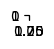

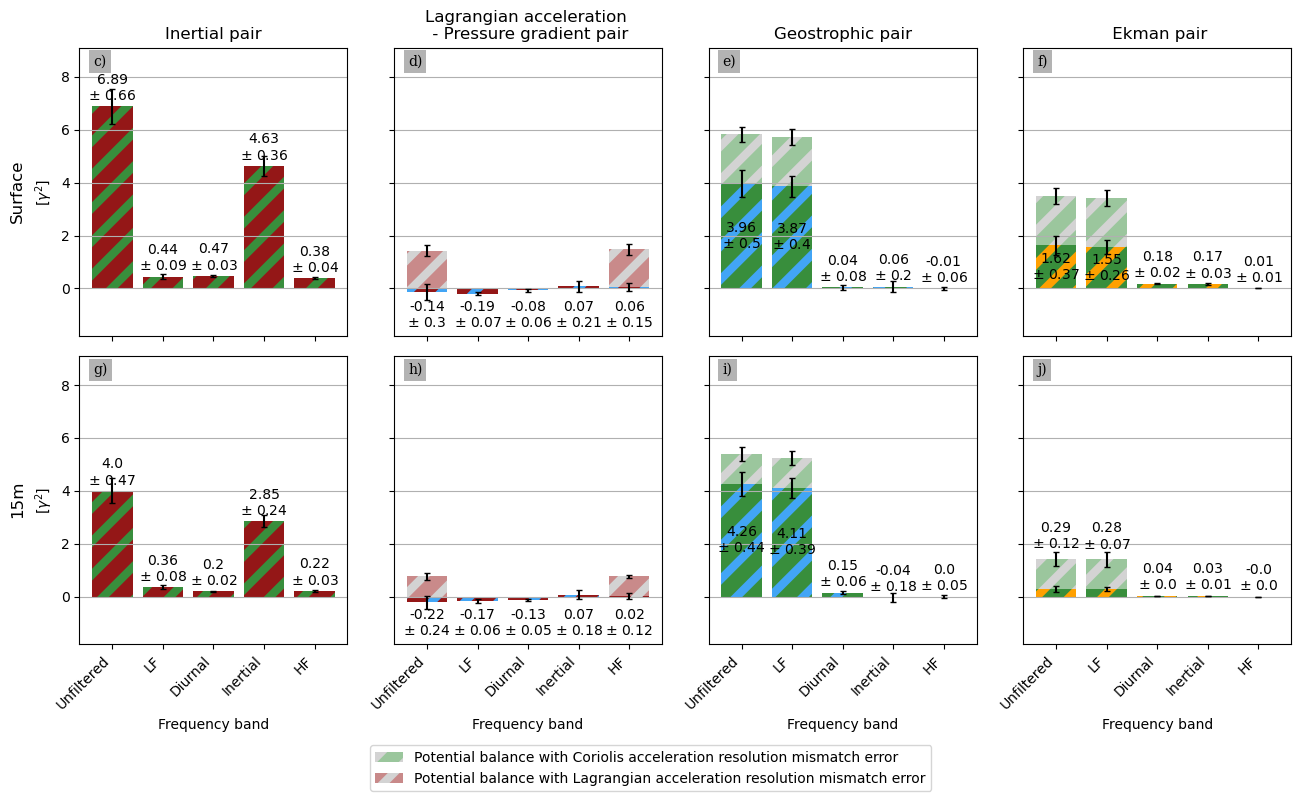

In [40]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
# ax.bar(0,1, color=c0['ggd'], label='Pressure gradient')
# ax.bar(0,1, color=c0['wd'], label='Wind term')
# ax.bar(0,1, color='lightgrey', label='Balanced Coriolis resolution mismatch error ?')
plt.rcParams["hatch.color"] = "lightgrey"
ax.bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
    label="Potential balance with Coriolis acceleration resolution mismatch error",
)
ax.bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    color=c0["acc"],
    alpha=0.5,
    **kwargs,
    label="Potential balance with Lagrangian acceleration resolution mismatch error",
)


handles, labels = ax.get_legend_handles_labels()


def print_labels(df, X, ax):
    for i in range(0, 5):
        # SX = df.iloc[i][[v for v in df.columns if ('B_' in v)&('er__' not in v)]].sum()
        label = (
            rf"{np.round(df[X].iloc[i], 2)}"
            + "\n"
            + rf"$\pm$ {np.round(df['er__' + X].iloc[i], 2)}"
        )
        # if i in [0, 1, 3] :
        #    label = label + '\n' + f"{int(df[X].iloc[i]/SX*100)}%"
        if X == "X_acc_ggd":
            vpos = -1
        elif (df[X].iloc[i] > 1.5) & ("acc" not in X):
            vpos = df[X].iloc[i] / 2
        elif (df[X].iloc[i] < 1.5) & ("cor_wd" in X) & (i < 2):
            vpos = df[X].iloc[i] + 2
        else:
            vpos = df[X].iloc[i] + 0.7
        ax.text(
            i,
            vpos,
            label,
            horizontalalignment="center",
            verticalalignment="center",
            rotation=0,
        )


plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(2, 4, figsize=(13, 8), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/", width=0.8, capsize=2)


def plot(df_, axs, init):
    ax = axs[init + 0]
    plt.rcParams["hatch.color"] = c0["cor"]
    df_.X_acc_cor.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__X_acc_cor"], **kwargs)
    print_labels(df_, "X_acc_cor", ax)

    ax = axs[init + 1]
    plt.rcParams["hatch.color"] = c0["ggd"]
    df_.X_acc_ggd.plot.bar(color=c0["acc"], ax=ax, yerr=df_["er__X_acc_ggd"], **kwargs)
    print_labels(df_, "X_acc_ggd", ax)

    ax = axs[init + 2]
    plt.rcParams["hatch.color"] = c0["ggd"]
    df_.X_cor_ggd.plot.bar(color=c0["cor"], ax=ax, yerr=df_["er__X_cor_ggd"], **kwargs)
    print_labels(df_, "X_cor_ggd", ax)

    ax = axs[init + 3]
    plt.rcParams["hatch.color"] = c0["wd"]
    df_.X_cor_wd.plot.bar(color=c0["cor"], ax=ax, yerr=df_["er__X_cor_wd"], **kwargs)
    print_labels(df_, "X_cor_wd", ax)


plot(df0.iloc[[0, 1, 2, 3, 5]], axs, 0)
plot(df15.iloc[[0, 1, 2, 3, 5]], axs, 4)

axs[0].set_title("Inertial pair")
axs[1].set_title("Lagrangian acceleration \n - Pressure gradient pair")
axs[2].set_title("Geostrophic pair")
axs[3].set_title(" Ekman pair")

pad = 0
axs[0].annotate(
    "Surface",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)
axs[4].annotate(
    "15m",
    xy=(-0.23, 0.5),
    xycoords="axes fraction",
    textcoords="offset points",
    size="large",
    ha="center",
    va="center",
    rotation=90,
)

l = ["c", "d", "e", "f", "g", "h", "i", "j"]
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

for ax in axs:
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_xticks(
        [0, 1, 2, 3, 4],
        ["Unfiltered", "LF", "Diurnal", "Inertial", "HF"],
        rotation=45,
        ha="right",
    )

axs[0].set_ylim(-1.8, 9.1)

#### Add Possible paired contributions from resolution mismatch ####
plt.rcParams["hatch.color"] = "lightgrey"
axs[2].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_ggd.loc["LF"],
    yerr=df0.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[3].bar(
    1,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_wd.loc["LF"],
    yerr=df0.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[2].bar(
    0,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_ggd.loc["Full-spectrum"],
    yerr=df0.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[3].bar(
    0,
    df0.E_cor.loc["LF"] * 2,
    bottom=df0.X_cor_wd.loc["Full-spectrum"],
    yerr=df0.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[6].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_ggd.loc["LF"],
    yerr=df15.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[7].bar(
    1,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_wd.loc["LF"],
    yerr=df15.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[6].bar(
    0,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_ggd.loc["Full-spectrum"],
    yerr=df15.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)
axs[7].bar(
    0,
    df15.E_cor.loc["LF"] * 2,
    bottom=df15.X_cor_wd.loc["Full-spectrum"],
    yerr=df15.er__E_cor.loc["LF"] * 2,
    color=c0["cor"],
    alpha=0.5,
    **kwargs,
)

plt.rcParams["hatch.color"] = "lightgrey"
axs[1].bar(
    4,
    df0.E_acc.loc["HF"] * 2,
    bottom=df0.X_acc_ggd.loc["HF"],
    yerr=df0.er__E_acc.loc["HF"] * 2,
    color=c0["acc"],
    alpha=0.5,
    **kwargs,
)
axs[1].bar(
    0,
    df0.E_acc.loc["HF"] * 2,
    yerr=df0.er__E_acc.loc["HF"] * 2,
    color=c0["acc"],
    alpha=0.5,
    **kwargs,
)
axs[5].bar(
    4,
    df15.E_acc.loc["HF"] * 2,
    yerr=df15.er__E_cor.loc["HF"] * 2,
    color=c0["acc"],
    alpha=0.5,
    **kwargs,
)
axs[5].bar(
    0,
    df15.E_acc.loc["HF"] * 2,
    yerr=df15.er__E_acc.loc["HF"] * 2,
    color=c0["acc"],
    alpha=0.5,
    **kwargs,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.legend(handles, labels, ncol=1, loc="lower center")

## Frequency bandm

In [41]:
def cpd_to_hours(x):
    return 24 / x

In [50]:
cpd_to_hours(0.88), cpd_to_hours(1.05), cpd_to_hours(1.75), cpd_to_hours(
    1.9
), cpd_to_hours(2.1)

(27.272727272727273,
 22.857142857142858,
 13.714285714285714,
 12.631578947368421,
 11.428571428571429)